## **Phi_4 with free boundary conditions**



## **I. Setup and Preprocessing**

In [18]:
# Import os library to access environment variables and operating system functionalities
import os

# Set environment variable to avoid duplicate library errors, specifically for OpenMP
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# Set TensorFlow log level to '2' to suppress most messages except warnings and errors
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
sys.path.append("../utilities")

# Import necessary libraries for deep learning and numerical computation
import tensorflow as tf
import numpy as np
from SREINet import * 
import DataGenerator as DG


# Print a formatted message to the terminal to display current time, date, and TensorFlow version
print("**********************************************")
print("*                                            *")
print("*    Tensorflow Version: " + tf.__version__ + "              *")
print("*                                            *")
print("**********************************************")

from packaging import version
if version.parse(tf.__version__) < version.parse('2.10.0') and version.parse(tf.__version__) > version.parse('2.15.0'):
    print("Error: Tensorflow version is lower than 2.10.0 or higher than 2.15.0 Please use Tensorflow 2.10.0 - 2.15.0")
    sys.exit()

MY_DATA_TYPE = 'float32'
# Set the desired data type
tf.keras.backend.set_floatx(MY_DATA_TYPE)  


**********************************************
*                                            *
*    Tensorflow Version: 2.15.0              *
*                                            *
**********************************************


### **1.2 Training Data**

#### Create dataset

Guess highest order polynomial: 3
(7500, 20)


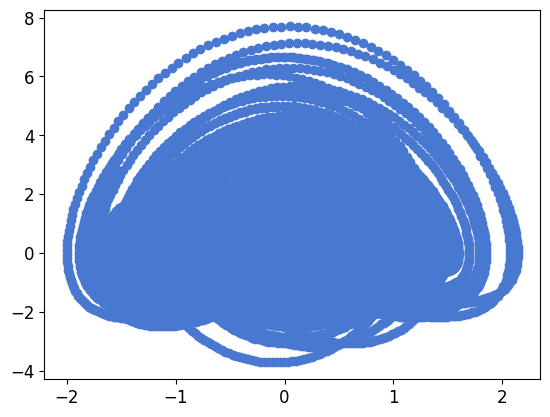

Raw input shape: (7500, 20)
Raw output shape: (7500, 20)


In [19]:
# Specify the model type
MY_MODEL = 'discrete_phi_quartic' 

SEED = 42  # set seed for random number generation
np.random.seed(SEED)


# Generate data based on the specified model type
node_num = 10 # number of nodes
C = 2.0 #coupling strength

#initial conditions for Simulation
xn = np.linspace(-node_num/2/np.sqrt(C), node_num/2/np.sqrt(C), node_num)

num_traj = 3
data_initial_conditions= []
for i in range(num_traj):

        x0 = np.random.normal(0, 0.1, size=xn.shape)  # random initial position
        d_x0 = np.random.normal(0, 0.1, size=xn.shape)  # random initial velocity

        new_IC = np.concatenate((x0, d_x0), axis=0) 
        data_initial_conditions.append(new_IC)

data_T =  25.0       # Length of the data (T)
data_dt = 0.01     # Resolution of the data (dt)
myDG = DG.DataGenerator(data_initial_conditions,T=data_T, dt=data_dt, random_state=SEED)

t_arr, x_train, dx_train, guess_highest_order_polynomial = myDG.generate_dataset_by_model_name(MY_MODEL, C, node_num, method='DOP853')

print("Guess highest order polynomial:", guess_highest_order_polynomial)

#plot x_train and dx_train
import matplotlib.pyplot as plt
print(x_train.shape)
plt.scatter(x_train, dx_train)
plt.show()

#Shuffle data
raw_input, raw_output = x_train, dx_train

print("Raw input shape:", raw_input.shape)
print("Raw output shape:", raw_output.shape)

#### Polynomial candidate functions (degree 3)


In [20]:
import pysindy as ps

# Build polynomial features up to degree 3 using PySINDy
state_labels = [f'x{i}' for i in range(1, x_train.shape[1] + 1)]
poly_library = ps.PolynomialLibrary(degree=3, include_bias=False)
poly_library.fit(x_train)

candidate_functions = poly_library.transform(x_train)
candidate_feature_names = poly_library.get_feature_names(input_features=state_labels)

print("Candidate feature matrix shape:", candidate_functions.shape)
print("First 10 candidate names:", candidate_feature_names[:10])

# Use polynomial candidates as the training input for SREINet
training_input = candidate_functions.astype(np.float32)
training_output = raw_output.astype(np.float32)
print("Training input shape:", training_input.shape)
print("Training output shape:", training_output.shape)


Candidate feature matrix shape: (7500, 1770)
First 10 candidate names: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10']
Training input shape: (7500, 1770)
Training output shape: (7500, 20)


### **1.3 Hyperparameters**



In [21]:
# Set mini-batch size
MINI_BATCH_SIZE = 32
learning_rate = 0.001

### **1.4 Model Architecture Definitions**

**SREINet Parameters**


In [22]:
# Assign dim to be the 2nd dimension of the training data (number of input variables, including the added constant 1)
dim = training_input.shape[1]

# Use a single-layer SREINet fed by the polynomial candidate features
layer_depth = 1
layer_neuron_nums_per_act_fn = [dim]
print(layer_neuron_nums_per_act_fn) # excluding the constant term; NOT the total number of neurons per layer


[1770]


## **II. Model and Training Preparation**


### **2.1 Create the SREINet Model**


In [23]:
activation_fns = [lambda x:x]
inputs = tf.keras.layers.Input(shape=(dim,), dtype=MY_DATA_TYPE)
model = SREINet(layer_neuron_nums_per_act_fn, 
                     activations=activation_fns,
                     data_type=MY_DATA_TYPE,
                     weight_initializer=tf.initializers.random_normal(stddev=1e-4, seed=SEED),
                     name='SREINet')
output = model(inputs)
model = tf.keras.Model(inputs=inputs, outputs=output)


### **2.2 Loss Function**

In [24]:
LOSS_FUNCTION = 'mse' #This can be 'MSE', 'LASSO', or 'RIDGE' or 'ElasticNet'(case insensitive)
 
from loss import *

# Example of selecting a loss function
loss_fn = myLoss(model, LOSS_FUNCTION) 

### **2.3 Optimizer**

In [25]:
my_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)  # Create an Adam optimizer with the defined learning rate

### **2.4 trainer**


In [26]:
from sreinet_trainer import *

trainer = SREINetTrainer(model, my_optimizer, loss_fn, data_type='float32')

## **III.Training the Model**


#### **Pruning Profile**


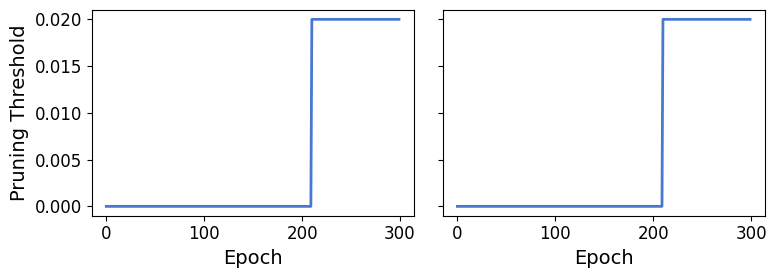

In [ ]:
MAX_WEIGHT_PRUNING_THRESHOLD = 0.02 #.3-.35 
N_PERIODS = 1
PRUNING_EPOCHS_PER_PERIOD = 300
NUM_EPOCHS = PRUNING_EPOCHS_PER_PERIOD * N_PERIODS

import pruning_scheduler as ps

pruning_scheduler = ps.PruningScheduler(steps_per_period=PRUNING_EPOCHS_PER_PERIOD, 
                    num_periods=N_PERIODS,
                    maximum_threshold=MAX_WEIGHT_PRUNING_THRESHOLD,
                    zero_percentage=0.7,
                    ramp_percentage=0.0,
                    show_plot=True)


In [28]:
callbacks = []

EARLY_STOPPING_LOSS_THRESHOLD = 1e-10   # Threshold for early stopping (Layer Based)
EARLY_STOPPING_PRUNING_THRESHOLD = 0.0

training_histories = []
weights_list = []
loss_list = []


In [29]:
print(f"Total Dimensions: {training_output.shape[1]}")
for i in range(0,training_output.shape[1]):
    print(f"Training dimension {i + 1}...")
    
    output = training_output[:, i:i+1]
    
    history = trainer.fit(training_input, output,
     batch_size=MINI_BATCH_SIZE, 
     validation_split=0.20,
     epochs=round(NUM_EPOCHS), 
     pruning_scheduler=pruning_scheduler,
     early_stopping_loss_threshold=EARLY_STOPPING_LOSS_THRESHOLD,
     early_stopping_pruning_threshold=EARLY_STOPPING_PRUNING_THRESHOLD,
     patience_periods=20,
     verbose=1,
    )
    training_histories.append(history)

    # Retrieve the weights of the trained model
    weights_list.append([trainer.get_best_weights()])
    loss_list.append(trainer.get_best_loss())

    #reset the model and trainer
    trainer.reset_trainer_and_model_weights(i)

Total Dimensions: 20
Training dimension 1...
Epoch   1 (Period 1):  Train Loss: 5.036e-02,  Validation Loss: 8.222e-03,  Epoch Time: 0.39s,  Current Pruning Threshold: 0
Epoch   2 (Period 1):  Train Loss: 5.574e-03,  Validation Loss: 6.190e-03,  Epoch Time: 0.17s,  Current Pruning Threshold: 0
Epoch   3 (Period 1):  Train Loss: 1.227e-02,  Validation Loss: 4.452e-02,  Epoch Time: 0.17s,  Current Pruning Threshold: 0
Epoch   4 (Period 1):  Train Loss: 1.036e-02,  Validation Loss: 1.784e-03,  Epoch Time: 0.17s,  Current Pruning Threshold: 0
Epoch   5 (Period 1):  Train Loss: 2.394e-03,  Validation Loss: 5.113e-03,  Epoch Time: 0.17s,  Current Pruning Threshold: 0
Epoch   6 (Period 1):  Train Loss: 3.948e-03,  Validation Loss: 1.102e-03,  Epoch Time: 0.16s,  Current Pruning Threshold: 0
Epoch   7 (Period 1):  Train Loss: 1.043e-03,  Validation Loss: 1.213e-03,  Epoch Time: 0.16s,  Current Pruning Threshold: 0
Epoch   8 (Period 1):  Train Loss: 1.708e-03,  Validation Loss: 1.610e-03,  Epoc